In [ ]:
!pip install statsbombpy
import numpy as np
import pandas as pd
from statsbombpy import sb

# 1. Recupero eventi del match: Spagna vs Inghilterra (Finale Euro 2024)
match_id = 3943043
events = sb.events(match_id=match_id)

# 2. Filtriamo solo i tiri nei tempi regolamentari con xG registrato
shots = events[
    (events['type'] == 'Shot') &
    (events['period'] <= 2)
][['team', 'minute', 'player', 'shot_statsbomb_xg', 'shot_outcome']].dropna(subset=['shot_statsbomb_xg'])

# 3. Isoliamo i due team e i rispettivi array di xG
teams = shots['team'].unique()
team_a, team_b = "Spain", "England"

xg_a = shots[shots['team'] == team_a]['shot_statsbomb_xg'].to_numpy()
xg_b = shots[shots['team'] == team_b]['shot_statsbomb_xg'].to_numpy()

print(f"=== DATI TIRI (90 MINUTI) ===")
print(f"{team_a}: {len(xg_a)} tiri | xG Totale: {xg_a.sum():.2f}")
print(f"{team_b}: {len(xg_b)} tiri | xG Totale: {xg_b.sum():.2f}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 2.9 MB/s eta 0:00:00


/usr/local/lib/python3.13/dist-packages/statsbombpy/api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


=== DATI TIRI (90 MINUTI) ===
Spain: 16 tiri | xG Totale: 1.79
England: 9 tiri | xG Totale: 0.73


In [ ]:
# Fissiamo un seed per la riproducibilità dei risultati
np.random.seed(42)

N_SIMS = 100_000

# Matrici di numeri casuali uniformi [0, 1)
# Forma: (N_SIMS, numero_tiri)
rand_a = np.random.uniform(0, 1, size=(N_SIMS, len(xg_a)))
rand_b = np.random.uniform(0, 1, size=(N_SIMS, len(xg_b)))

# Se il numero casuale è minore dell'xG, è gol (True = 1, False = 0)
sim_goals_a = (rand_a < xg_a).sum(axis=1)
sim_goals_b = (rand_b < xg_b).sum(axis=1)

# Calcolo probabilità esiti (Vittoria Spagna, Pareggio, Vittoria Inghilterra)
p_win_spain = np.mean(sim_goals_a > sim_goals_b) * 100
p_draw = np.mean(sim_goals_a == sim_goals_b) * 100
p_win_england = np.mean(sim_goals_a < sim_goals_b) * 100

# Expected Points (xPTS)
xpts_spain = (3 * (p_win_spain / 100)) + (1 * (p_draw / 100))
xpts_england = (3 * (p_win_england / 100)) + (1 * (p_draw / 100))

print("=== RISULTATI MONTE CARLO (100.000 SIMULAZIONI) ===")
print(f"P(Vittoria Spagna):      {p_win_spain:.2f}%")
print(f"P(Pareggio nei 90'):     {p_draw:.2f}%")
print(f"P(Vittoria Inghilterra): {p_win_england:.2f}%")
print("-" * 50)
print(f"Expected Points (xPTS) Spagna:      {xpts_spain:.2f}")
print(f"Expected Points (xPTS) Inghilterra: {xpts_england:.2f}")

=== RISULTATI MONTE CARLO (100.000 SIMULAZIONI) ===
P(Vittoria Spagna):      64.62%
P(Pareggio nei 90'):     22.09%
P(Vittoria Inghilterra): 13.28%
--------------------------------------------------
Expected Points (xPTS) Spagna:      2.16
Expected Points (xPTS) Inghilterra: 0.62


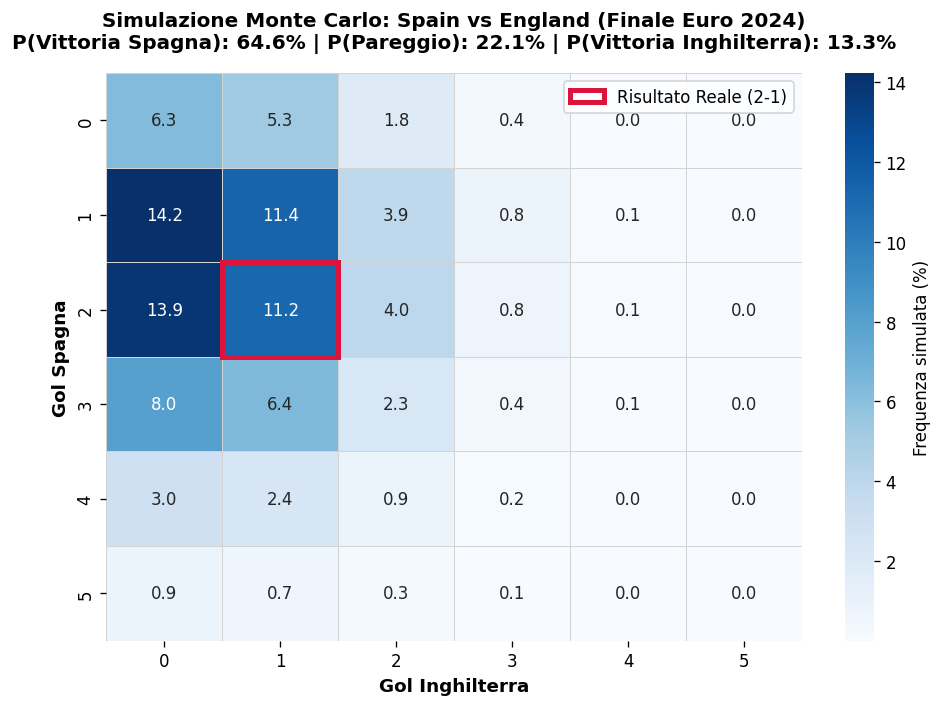

Probabilità del risultato reale (2-1): 11.22%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creazione della tabella di contingenza per i punteggi (max 5 gol per squadra)
max_goals = 5
score_matrix = pd.crosstab(
    pd.Series(sim_goals_a, name="Gol Spagna"),
    pd.Series(sim_goals_b, name="Gol Inghilterra"),
    normalize=True
) * 100

# Riordiniamo e limitiamo la matrice da 0 a 5 gol
score_matrix = score_matrix.reindex(index=range(max_goals + 1), columns=range(max_goals + 1), fill_value=0)

# 2. Setup grafico
fig, ax = plt.subplots(figsize=(8, 6), dpi=120)

sns.heatmap(
    score_matrix,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={'label': 'Frequenza simulata (%)'},
    linewidths=0.5,
    linecolor='lightgrey',
    ax=ax
)

# Evidenziamo il risultato reale (Spagna 2 - 1 Inghilterra)
# Nota: in heatmap y=righe (Spagna=2), x=colonne (Inghilterra=1)
rect = plt.Rectangle((1, 2), 1, 1, fill=False, edgecolor='crimson', lw=3, label="Risultato Reale (2-1)")
ax.add_patch(rect)

# 3. Styling e annotazioni
plt.title(
    f"Simulazione Monte Carlo: {team_a} vs {team_b} (Finale Euro 2024)\n"
    f"P(Vittoria Spagna): {p_win_spain:.1f}% | P(Pareggio): {p_draw:.1f}% | P(Vittoria Inghilterra): {p_win_england:.1f}%",
    fontsize=12, pad=15, weight='bold'
)
plt.xlabel("Gol Inghilterra", fontsize=11, weight='bold')
plt.ylabel("Gol Spagna", fontsize=11, weight='bold')
plt.legend(handles=[rect], loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

# 4. Probabilità specifica del 2-1
real_score_prob = score_matrix.loc[2, 1]
print(f"Probabilità del risultato reale (2-1): {real_score_prob:.2f}%")